In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import CoolProp.CoolProp as CP
import numpy as np
from tenacity import P


def load_data():
    path_to_file = '../data/vrv-transfer-learning/transfer_learning_RQYP224FC_20260225.parquet'
    df = pd.read_parquet(path_to_file)
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df = df.sort_values('timestamp').reset_index(drop=True)
    return df

# pH線図の背景（飽和線）を描画する関数
def plot_ph_background(fluid_name="R410A",color='black'):
    Tc = CP.PropsSI('Tcrit', fluid_name)
    T_min = 223.15  # -50 degC
    T_range = np.linspace(T_min, Tc - 0.1, 100)
    
    h_l = [CP.PropsSI('H', 'T', T, 'Q', 0, fluid_name) / 1000 for T in T_range]
    p_l = [CP.PropsSI('P', 'T', T, 'Q', 0, fluid_name) / 1e6 for T in T_range]
    h_v = [CP.PropsSI('H', 'T', T, 'Q', 1, fluid_name) / 1000 for T in T_range]
    p_v = [CP.PropsSI('P', 'T', T, 'Q', 1, fluid_name) / 1e6 for T in T_range]
    
    #plt.plot(h_l, p_sat, 'k-', lw=1.5, alpha=0.7)
    #plt.plot(h_v, p_sat, 'k-', lw=1.5, alpha=0.7)

    plt.plot(h_l, p_l, color=color, lw=2, label=f'{fluid_name} Sat. Curve')
    plt.plot(h_v, p_v, color=color, lw=2)

    # --- 2. 等温線の追加 ---
    # 表示したい温度（Celsius）を設定
    T_celsius = [0, 20, 40, 60, 80, 100]
    # 圧力の描画範囲（y軸の範囲に合わせる）
    p_range = np.geomspace(0.5e6, 10e6, 100) # 0.5MPaから10MPaまで

    for Tc in T_celsius:
        T_kelvin = Tc + 273.15
        h_isotherm = []
        p_isotherm = []
        
        for p in p_range:
            try:
                # 指定した温度・圧力でのエンタルピーを計算
                h = CP.PropsSI('H', 'T', T_kelvin, 'P', p, fluid_name) / 1000
                h_isotherm.append(h)
                p_isotherm.append(p / 1e6)
            except:
                continue # 物性値が計算できない範囲（超臨界など）はスキップ
        
        plt.plot(h_isotherm, p_isotherm, 'k:', lw=1, alpha=0.6)
        # 線の上に温度をテキスト表示（適当な位置：P=1.0MPa付近）
        if h_isotherm:
            plt.text(h_isotherm[10], p_isotherm[10], f'{Tc}°C', fontsize=9, color='black')




def plot_refrigeration_cycle_modify(current_row,  # data frame row
                                    fluid_name="R410A"):
    """
    実測データに基づき、冷凍サイクルの詳細な各動作点をpH線図上にプロットする。

    Args:
        T_evap_C (float): 蒸発温度 [°C] (低圧側飽和圧力算出用)
        T_cond_C (float): 凝縮温度 [°C] (高圧側飽和圧力算出用)
        T_dis_C (float): 圧縮機吐出温度 [°C]
        T_accum_in_C (float): アキュムレータ入口温度 [°C] (吸入点)
        T_cond_out_C (float): 凝縮器出口温度 [°C]
        T_airout_C (float): 室外機外気温 [°C] (比較参照点)
        T_liquidpipe_C (float): 液管温度 [°C]
        T_doubleHX_C (float): 二重管熱交出口温度 [°C] (過冷却ガス間温度)
        T_indoor_gas_C (室内機熱交換器のガス管温度)
        fluid_name (str): 冷媒名 (デフォルト "R410A")

    Returns:
        dict: 各計算ポイントのエンタルピ [kJ/kg] と圧力 [MPa]
    """
    plot_ph_background('R410A', 'black')

    try:
        # スライダーで選ばれた時刻のデータを使用して計算
        T_eg_C = current_row['teg'] # 圧縮機入口のガス飽和温度
        T_cg_C = current_row['tcg'] # # 圧縮機出口のガス飽和温度
        
        T_dis_C = current_row['compressor_1_dischargetemp']
        T_accum_in_C = current_row['ts'] #アキュムレータ入口温度
        T_cond_out_C = current_row['t_liquid']      # 凝縮器出口
        T_airout_C = 35.0        # 外気温（仮設定）
        T_liquidpipe_C = current_row['t_liquid']  # 液管温度(データがないので't_liquid'を入れる)
        T_doubleHX_C = current_row['tsh']      # 二重管
        T_indoor_liquid_C = current_row['indoor_liquid']
        T_indoor_gas_C = current_row['indoor_gas']      # 室内機熱交換器のガス（気相）
        fluid_name = "R410A"

        #st.write(T_liquidpipe_C,T_doubleHX_C)
        
        # --- 圧力・エンタルピ計算 ---
        P_eg_Pa = CP.PropsSI('P', 'T', T_eg_C + 273.15, 'Q', 1, fluid_name)
        P_cg_Pa = CP.PropsSI('P', 'T', T_cg_C + 273.15, 'Q', 0, fluid_name)

        T_indoor_mean = (T_indoor_gas_C + T_indoor_liquid_C) / 2
        P_indoor_mean_Pa = CP.PropsSI('P', 'T', T_indoor_mean + 273.15, 'Q', 0, fluid_name) # 蒸発器の圧力を液管とガス管の平均温度で算出する

        C_K_convert = 273.15
        
        P_eg_MPa = P_eg_Pa / 1e6
        P_cg_MPa = P_cg_Pa / 1e6
        P_indoor_mean_MPa = P_indoor_mean_Pa / 1e6

        # R410Aなどの非共沸冷媒は、Q=0.5などでCoolPropに入力するとエラーになる
        # P_doubleHX_Pa = CP.PropsSI('P','T', T_doubleHX_C + 273.15,'Q',0.5,fluid)
        # P_doubleHX_Pa = CP.PropsSI('P','T', T_doubleHX_C + 273.15,'Q',1.0,fluid)
        # P_doubleHX_MPa = P_doubleHX_Pa / 1e6


        def get_h(T_C, P_Pa, fluid):
            T_K = T_C + 273.15
    
            try:
                # 指定したT, Pで直接計算を試みる（単相域：過冷却液 or 過熱蒸気）
                return CP.PropsSI('H', 'T', T_K, 'P', P_Pa, fluid) / 1000.0
            
            except ValueError:
                # T, Pが飽和域にある場合、あるいは境界上の場合はエラーになるため
                # 飽和蒸気の値を返すなどの例外処理が必要
                print("Warning: State is in the saturation region or input is invalid.")
                return None

        h_inlet = get_h(T_accum_in_C, P_eg_Pa,fluid_name)       # Inlet (Accumu In)
        h_dis = get_h(T_dis_C, P_cg_Pa,fluid_name)             # Discharge
        h_cond_out = get_h(T_cond_out_C, P_cg_Pa,fluid_name)   # Condenser Out
        h_airout = get_h(T_airout_C, P_cg_Pa,fluid_name)  # Condenser (Air outdoorunit) 外気温度
        h_cond_liquid = get_h(T_liquidpipe_C, P_cg_Pa,fluid_name) # Condenser Liquid pipe
        
        h_doubleHX_in = h_cond_out  # 二重管入口　凝縮器出口のエンタルピーは同じ
        h_doubleHX_out = get_h(T_doubleHX_C,P_eg_Pa,fluid_name) # DoubleHX out 　二重管出口のエンタルピーは過冷却管温度から算出する
        
        h_indoor_gas = get_h(T_indoor_gas_C, P_indoor_mean_Pa,fluid_name) # 室内ガス管
        print(h_indoor_gas)
        h_indoor_liquid = get_h(T_indoor_liquid_C, P_indoor_mean_Pa,fluid_name) # 室内液管
        print(h_indoor_liquid)

        # 飽和線の交点（補助用）
        h_cond_gas = CP.PropsSI('H', 'P', P_cg_Pa, 'Q', 1, fluid_name) / 1000.0
        h_cond_liquid_sat = CP.PropsSI('H', 'P', P_cg_Pa, 'Q', 0, fluid_name) / 1000.0

       
        # --- 3. プロット (Points) ---
        pts = [
            (h_inlet, P_eg_MPa, 'bs', "Inlet(Accumu In)"),
            (h_indoor_gas, P_indoor_mean_MPa, 'bo', "IndoorUnit Gas"),
            (h_indoor_liquid, P_indoor_mean_MPa, 'bo', "IndoorUnit liquid"),
            (h_dis, P_cg_MPa, 'rs', "Discharge"),
            (h_cond_out, P_cg_MPa, 'gs', "Condenser Out"),
            (h_cond_gas, P_cg_MPa, 'gx', "Condenser Gas"),
            (h_cond_liquid, P_cg_MPa, 'bs', "Condenser Liquid pipe"),
            (h_doubleHX_in, P_eg_MPa, 'go', "DoubleHX in (EVT out)"),
            (h_doubleHX_out, P_eg_MPa, 'go', "DoubleHX out "),
            (h_airout, P_cg_MPa, 'm.', "Outdoor Unit (Air out)"), # 外気温度 
            (h_cond_out, P_eg_MPa, '.', "Evaporator In")
        ]

        #st.write('DoubleHX out Enthalpy=',h_doubleHX_out,'Enthalpy (Evap gas)=',h_evap_indoor_gas)
        #st.write('SC: T_cg - T_liquidpipe_cg',T_cond_C - T_liquidpipe_C)
        #st.write('SH (evap): T_indoor_gas - T_eg',T_indoor_gas_C - T_evap_C)
        #st.write('SH (doubleHX):T_doubleHX - T_eg',T_doubleHX_C - T_evap_C)

        for h, p, style, lbl in pts:
            plt.plot(h, p, style, label=lbl)

        # --- 4. プロット (Lines) ---
        # 圧縮工程
        plt.plot([h_inlet, h_dis], [P_eg_MPa, P_cg_MPa], 'r-', lw=2, label="Compression")
    
        # 凝縮工程 (吐出 -> 凝縮器出口)
        plt.plot([h_dis, h_cond_out], [P_cg_MPa, P_cg_MPa], 'y-', lw=2)
    
        # サブクール・液管・二重管ライン
        #plt.plot([h_cond_out, h_cond_airout], [P_cond_MPa, P_cond_MPa], 'b-', lw=1.5)
        #plt.plot([h_cond_airout, h_cond_liquid], [P_cond_MPa, P_cond_MPa], 'b-', lw=1.5)
        #plt.plot([h_cond_airout, h_doubleHX_in], [P_cond_MPa, P_cond_MPa], 'b-', lw=1.5)
    
        # 蒸発器ライン (膨張弁通過後の等エンタルピ想定)
        # ここでは h_cond_out を基準点として蒸発器入口へつなぐ
        plt.plot([h_cond_out, h_inlet], [P_eg_MPa, P_eg_MPa], 'b--', lw=2, label="Evaporator line")

        # 膨張弁 (等エンタルピ)
        plt.plot([h_cond_out, h_cond_out], [P_cg_MPa, P_eg_MPa], 'g--', lw=1)

        # 二重管熱交換器のライン
        plt.plot([h_cond_out, h_doubleHX_out], [P_eg_MPa, P_eg_MPa], 'g--:', lw=1)

        # 室内機の液管、ガス管のライン
        plt.plot([h_indoor_gas, h_indoor_liquid], [P_indoor_mean_MPa, P_indoor_mean_MPa], 'b--', lw=1) 
        
        plt.set_yscale('log')
        plt.set_xlim(100, 600)
        plt.set_ylim(0.5, 5.0) # 圧力範囲はデータに合わせて調整
        plt.set_xlabel('Enthalpy [kJ/kg]')
        plt.set_ylabel('Pressure [MPa]')
        plt.grid(True, which="both", alpha=0.3)
        #ax.legend()

        # ax.legend(loc='best', borderaxespad=0, fontsize='small')
        plt.legend(loc='upper left', fontsize='small') 

    except Exception as e:
        print(f"この時刻の物性計算ができませんでした: {e}")

In [67]:
df_current_times = load_data()
#plot_ph_background()
#df_current_times
# queryを使う方法
current_times = df_current_times.query('timestamp == "2023-08-21 06:25"')

df_current_times.head()


/var/folders/7b/1jnhctp97vxgzcrx3cgf_wyw0000gn/T/ipykernel_19339/673422882.py:5: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  current_times = df_current_times.query('timestamp == "2023-08-21 06:25"')


,timestamp,tcg,t_liquid,rpm,teg,ts,tsh,compressor_1_dischargetemp,refrigerantpipe_1_highpressure,compressor_coolingfin_temp,compressor_surface_temp,outdoor_deicer_temp,stopvalve_liquid_temp,subcool_mov_flowratio,indoor_liquid,indoor_gas,indoor_ev_pulse
0,2023-08-01 00:00:00,41.062500,31.0,108.0,2.703125,13.699219,3.0,67.0,2.378901,44.0,63.0,36.0,11.097656,39.5,5.250000,10.234375,383.0
1,2023-08-01 00:00:00,41.175781,31.0,99.0,4.332031,14.199219,5.0,64.0,2.385597,46.0,58.0,34.0,14.097656,35.5,6.562500,10.968750,370.0
2,2023-08-01 00:00:00,39.082031,30.0,95.0,2.781250,13.597656,3.0,63.0,2.264154,42.0,60.0,33.0,10.097656,36.5,4.921875,9.750000,356.0
3,2023-08-01 00:00:00,35.277344,30.0,55.0,5.363281,16.500000,5.0,57.0,2.054752,38.0,52.0,28.0,10.898438,18.5,6.312500,12.375000,276.0
4,2023-08-01 00:05:00,41.742188,31.0,108.0,3.035156,13.597656,3.0,67.0,2.419302,43.0,63.0,35.0,11.097656,40.0,5.421875,10.234375,383.0


In [79]:

p_evap =CP.PropsSI('P', 'T', 10  + 273.15, 'Q', 1, 'R410A')

CP.PropsSI('H', 'T', 5.25 + 273.15, 'P', p_evap, 'R410A') / 1000.0 # liquid
CP.PropsSI('H', 'T', 15 + 273.15, 'P', p_evap, 'R410A') / 1000.0 # Gas

430.015304859615

426.550641244284
211.8457924323941
この時刻の物性計算ができませんでした: module 'matplotlib.pyplot' has no attribute 'set_yscale'


/var/folders/7b/1jnhctp97vxgzcrx3cgf_wyw0000gn/T/ipykernel_19339/613910124.py:100: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  P_eg_Pa = CP.PropsSI('P', 'T', T_eg_C + 273.15, 'Q', 1, fluid_name)
/var/folders/7b/1jnhctp97vxgzcrx3cgf_wyw0000gn/T/ipykernel_19339/613910124.py:101: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  P_cg_Pa = CP.PropsSI('P', 'T', T_cg_C + 273.15, 'Q', 0, fluid_name)
/var/folders/7b/1jnhctp97vxgzcrx3cgf_wyw0000gn/T/ipykernel_19339/613910124.py:104: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  P_indoor_mean_Pa = CP.PropsSI('P', 'T', T_indoor_mean + 273.15, 'Q', 0, fluid_name) # 蒸発器の圧力を液管とガス管の平均温度で算出する
/var/folders/7b/1jnhctp97vxgzcrx3cgf_wyw0000gn/T/ipykernel_19339/61391

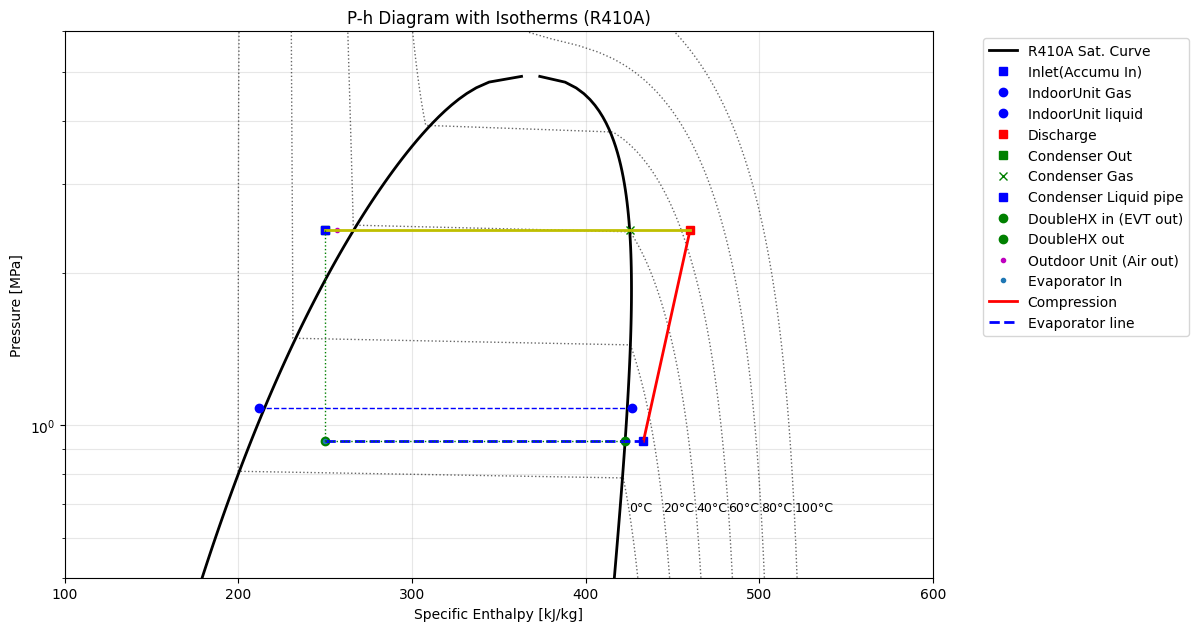

In [106]:
plt.figure(figsize=(12, 6))

plot_refrigeration_cycle_modify(current_times,'R410A')

plt.yscale('log')
plt.grid(True, which='both', ls='-', alpha=0.2)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# 仕上げ
plt.yscale('log')
plt.xlabel('Specific Enthalpy [kJ/kg]')
plt.ylabel('Pressure [MPa]')
plt.title('P-h Diagram with Isotherms (R410A)')
plt.grid(True, which="both", ls="-", alpha=0.3)

# 軸の範囲調整
plt.xlim(100, 600)
plt.ylim(0.5, 6)

plt.show()